# Тест примеры для поиска лучшего размещения подразделений алгоритмом Kopt

In [4]:
import numpy as np
import networkx as nx
import pandas as pd
import geopandas as gpd
from genesis.core import BestPointsBase, MetricBase, StateBase
from genesis.mclp import BestNodesKoptG
from genesis.best_points import BestNodeHillClimbing
from genesis.states import FirstArrivalUnitState
from genesis.metrics import ArrivalTime, CoverIndex
from genesis.tools import list_dict_concat, kmh_to_mm
from genesis.utils import timing
import matplotlib.pyplot as plt
from genesis.swiss_knife import CMAP_GrGldRd

import osmnx as ox

In [3]:
def load_G():
    return ox.load_graphml("tests/data/test_rng.ml")

def load_G_simplyfied():
    G = load_G()
    return ox.simplify_graph(G)

def load_area():
    return gpd.read_file("tests/data/test_polygon.gpkg")

def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

In [3]:
# Загрузка графа и полигона границ
G = load_G_simplyfied()
print(G.number_of_nodes())
area = load_area()

nodes = list(G.nodes())
existed_units = {nodes[100]:'A', 
                nodes[200]:'B', 
                }
new_units = {nodes[300]:'c',
             nodes[400]:'d'}

1941


In [5]:
def iter_func(**kwds):
        'Функция вывода хода расчета'
        print(kwds)

class IterFunc:
    def __init__(self):
        self.history = []

    def __call__(self, **kwds):
        'Функция вывода хода расчета'
        self.dynamic_nodes = kwds.get('dynamic_nodes')
        self.static_nodes = kwds.get('static_nodes')
        self.history.append(kwds)
        print(kwds)

## Расчет базовый с учетом статических и динамических узлов

In [9]:
BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))

ifunc = IterFunc()

optimal_nodes, best_metric = BNG(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=ifunc,
    )
print(optimal_nodes, best_metric)

ifunc.static_nodes

{'best_metric': 5.893246755850868, 'dynamic_nodes': {2034402245: 'псч-3', 2589929136: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 0, 'best_metric': 5.061464179918789, 'dynamic_nodes': {2034401857: 'псч-3', 1577738848: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 1, 'best_metric': 5.009175637652269, 'dynamic_nodes': {2034401857: 'псч-3', 6211105430: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 2, 'best_metric': 5.009175637652269, 'dynamic_nodes': {2034401857: 'псч-3', 6211105430: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 3, 'best_metric': 5.009175637652269, 'dynamic_nodes': {2034401857: 'псч-3', 6211105430: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 4, 'best_metric': 5.009175637652269, 'dynamic_nodes': {2034401857: 'псч-3', 6211105430: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
ВРЕМЯ: 2.48 сек
{2034401857: 'псч-3', 6211105430: 'псч-4'} 5.00917563765

{1543970277: 'A', 1555148537: 'B'}

In [6]:
nodes = list(G.nodes())
new_units = {
            nodes[500]:'псч-3',
            nodes[1000]:'псч-4',
            }

BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                    #    all_neighbors=False
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

{'best_metric': 6.565893771428573, 'dynamic_nodes': {2034402245: 'псч-3', 2589929136: 'псч-4'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 5.563807187855296, 'dynamic_nodes': {2034401857: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {}}
ВРЕМЯ: 4.55 сек


## Расчет в пределах некоторой области

In [7]:
# Определение маски расчета
nodes = ox.graph_to_gdfs(G, edges=False)
points_mask = nodes.within(area.iloc[0].geometry)

# Функция расчета лучшего узла
BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )

# Функция расчета лучшего размещения
BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))

# Функция отслеживания изменения состояния по мере расчета
ifunc = IterFunc()

optimal_nodes, best_metric = BNG(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    area=points_mask,
    before_iters_start_function=iter_func,
    iter_calc_end_function=ifunc,
    )
print(optimal_nodes, best_metric)

{'best_metric': 3.3607057933162725, 'dynamic_nodes': {2034402245: 'псч-3', 2589929136: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 0, 'best_metric': 2.991950826283306, 'dynamic_nodes': {2034401682: 'псч-3', 1296599777: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 1, 'best_metric': 2.80819499247328, 'dynamic_nodes': {2034401381: 'псч-3', 1644098162: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 2, 'best_metric': 2.7571691825982234, 'dynamic_nodes': {2034401374: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 3, 'best_metric': 2.7571691825982234, 'dynamic_nodes': {2034401374: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 4, 'best_metric': 2.7571691825982234, 'dynamic_nodes': {2034401374: 'псч-3', 426923846: 'псч-4'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
ВРЕМЯ: 5.2 сек
{2034401374: 'псч-3', 426923846: 'псч-4'} 2.7571691825982

## Тест использования перегруженной функции

In [11]:
class BestNodeHillClimbing_MaxMean(BestNodeHillClimbing):
    def __init__(self, 
                state_function: StateBase, 
                metric_function: MetricBase = None, 
                appr_val: float = 0.95, 
                all_neighbors: bool = False, 
                **kwargs) -> None:
        super().__init__(state_function, metric_function, appr_val, all_neighbors, **kwargs)

    def __call__(self, env: nx.MultiDiGraph, 
                area: pd.Series = None, 
                start_node: int = None, 
                **kwargs):
        bnch_max = BestNodeHillClimbing(state_function=self.state_function,
                                        metric_function=ArrivalTime(np.max), appr_val=self.appr_val, all_neighbors=self.all_neighbors)
        bnch_mean = BestNodeHillClimbing(state_function=self.state_function,
                                        metric_function=ArrivalTime(), appr_val=self.appr_val, all_neighbors=self.all_neighbors)

        best_node, best_metric = bnch_max(env=env, area=area, start_node=start_node)
        best_node, best_metric = bnch_mean(env=env, area=area, start_node=best_node)
        return best_node, best_metric
    
G = load_G_simplyfied()

nodes = list(G.nodes())
existed_units = {nodes[100]: 'A',
        nodes[200]: 'B',
        }
new_units = {nodes[300]: 'c',
            nodes[400]: 'd'}
BNHC = BestNodeHillClimbing_MaxMean(state_function=FirstArrivalUnitState())

BNG = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                    metric_function=ArrivalTime(),
                    best_point_function=BNHC,
                    iterations=5,
                    )

optimal_nodes, best_metric = BNG(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    )
optimal_nodes, best_metric

({2034401362: 'c', 2034401857: 'd'}, 5.3976885050203025)

## Тест расчета последовательно метриками Max Mean

In [12]:
G = load_G_simplyfied()

nodes = list(G.nodes())
existed_units = {nodes[100]: 'A',
        nodes[200]: 'B',
        }
new_units = {nodes[300]: 'c',
            nodes[400]: 'd'}

# Расчет метрикой max_time
BNHC_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(np.max),
                       )
BNG_max = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_max,
                       iterations=5,
                       ))
optimal_nodes, best_metric = BNG_max(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
# Расчет метрикой mean_time
BNHC_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )
BNG_mean = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_mean,
                       iterations=5,
                       ))
optimal_nodes, best_metric = BNG_mean(env=G,
    static_nodes=existed_units,
    dynamic_nodes=optimal_nodes,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
print(optimal_nodes, best_metric)

{'best_metric': 7.569996473754152, 'dynamic_nodes': {2034401317: 'c', 2034401867: 'd'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 5.709866702694722, 'dynamic_nodes': {1998227466: 'c', 426923809: 'd'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 5.709866702694722, 'dynamic_nodes': {1998227466: 'c', 426923809: 'd'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 5.709866702694722, 'dynamic_nodes': {1998227466: 'c', 426923809: 'd'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 5.709866702694722, 'dynamic_nodes': {1998227466: 'c', 426923809: 'd'}, 'static_nodes': {}}
{'i': 4, 'best_metric': 5.709866702694722, 'dynamic_nodes': {1998227466: 'c', 426923809: 'd'}, 'static_nodes': {}}
ВРЕМЯ: 5.84 сек
{'best_metric': 5.35616866688815, 'dynamic_nodes': {1998227466: 'c', 426923809: 'd'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 0, 'best_metric': 5.066533988851974, 'dynamic_nodes': {1577738848: 'c', 2034401777: 'd'}, 'static_nodes': {1543970277: 'A', 1555148537: 'B'}}
{'i': 1, 'best_

# Расчет для сравнения с ГА и ИО

In [6]:
def iter_state_func(**kwds):
    '''
    Печать состояния расчета на итерации
    '''
    # print('Итерация:', kwds['i'])
    print(kwds)
    dynamic_nodes = kwds['dynamic_nodes']
    if isinstance(dynamic_nodes, dict):
        dynamic_nodes_id = list(dynamic_nodes.keys())
    else:
        dynamic_nodes_id = dynamic_nodes

    try:
        static_nodes = kwds['static_nodes']
        if isinstance(static_nodes, dict):
            static_nodes_id = list(static_nodes.keys())
        else:
            static_nodes_id = static_nodes
    except:
        static_nodes = None
        
    if not static_nodes is None:
        if isinstance(dynamic_nodes,list):
            start_nodes = dynamic_nodes+static_nodes
        elif isinstance(dynamic_nodes,dict):
            start_nodes = {**dynamic_nodes, **static_nodes}
    else:
        start_nodes = dynamic_nodes
    times, nearest = FirstArrivalUnitState()(env=G, points=start_nodes)
    times = {k:(1+int(t//5))*5 for k, t in times.items()}

    nx.set_node_attributes(G, pd.Series(nearest, dtype=str), 'nearest')
    nx.set_node_attributes(G, times, 'route_time')

    nds = ox.graph_to_gdfs(G, edges=False)
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
    nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3', legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax1, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax1, markersize=25, color='k')

    ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
    nds.plot(ax=ax2, markersize=2, column='route_time', cmap=CMAP_GrGldRd, legend=True)
    nds.loc[dynamic_nodes_id].plot(ax=ax2, markersize=25, color='red')
    if static_nodes:
        nds.loc[static_nodes_id].plot(ax=ax2, markersize=25, color='k')

    plt.show()

In [12]:
G = load_G()

nodes = list(G.nodes())
existed_units = {nodes[100]: 'A',
        nodes[2000]: 'B',
        }
new_units = {nodes[3000]: 'c',
            nodes[4000]: 'd'}


BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))

ifunc = IterFunc()

optimal_nodes, best_metric = BNG(env=G,
    static_nodes=existed_units,
    dynamic_nodes=new_units,
    # before_iters_start_function=iter_func,
    iter_calc_end_function=ifunc,
    )
print(optimal_nodes, best_metric)



{'i': 0, 'best_metric': 6.987965887860777, 'dynamic_nodes': {2054468329: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{'i': 1, 'best_metric': 6.984608999416008, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{'i': 2, 'best_metric': 6.984608999416008, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{'i': 3, 'best_metric': 6.984608999416008, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
{'i': 4, 'best_metric': 6.984608999416008, 'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}
ВРЕМЯ: 2.87 сек
{4116059950: 'c', 5116722296: 'd'} 6.984608999416008


{'dynamic_nodes': {4116059950: 'c', 5116722296: 'd'}, 'static_nodes': {1296599762: 'A', 2042076750: 'B'}}


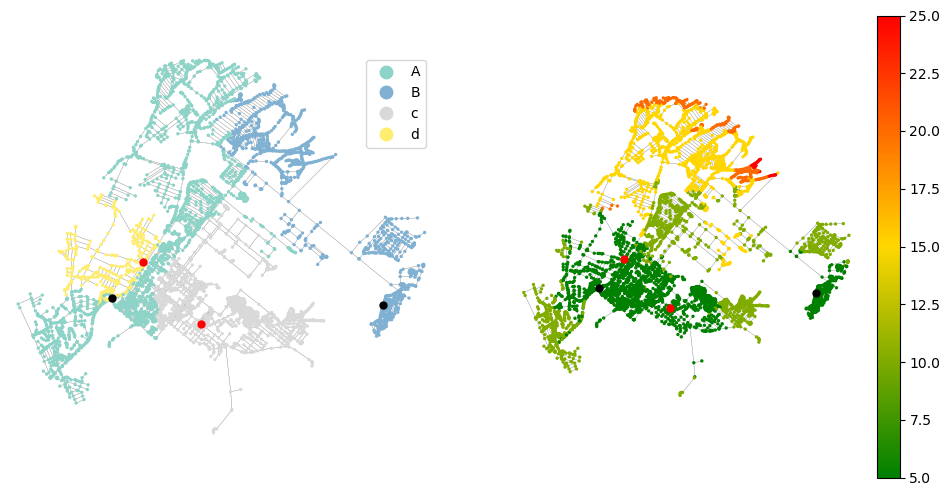

In [13]:
# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes, static_nodes=existed_units)

# Расчет для Красноярского графа

In [14]:
G = ox.graph_from_place('Красноярск, Россия')
print(G.number_of_nodes())

s1, s2, s3, s4, s5 = [49, 37, 26, 16, 5]
hwy_speeds = {
            "trunk":          s1,           # Важные дороги, не являющиеся автомагистралями
            "trunk_link":     s1,           # Важные дороги, не являющиеся автомагистралями
            "motorway":       s1,           # Автомагистрали 
            "motorway_link":  s1,           # Автомагистрали 
            
            "primary":        s2,           # Автомобильные дороги регионального значения
            "primary_link":   s2,           # Автомобильные дороги регионального значения
            "secondary":      s2,           # Автомобильные дороги областного значения
            "secondary_link": s2,           # Автомобильные дороги областного значения
            "unclassified":   s2,           # Остальные автомобильные дороги местного значения, образующие соединительную сеть дорог.

            "tertiary":       s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "tertiary_link":  s3,           # Более важные автомобильные дороги среди прочих автомобильных дорог местного значения
            "residential":    s3,           # Дороги, которые проходят внутри жилых зон, а также используются для подъезда к ним
            "living_street":  s3,           # Жилые зоны и дворовые проезды
            
            "road":           s4,           # Линии, возможно, являющиеся дорогами. Временный тег, которым следует помечать линии до уточнения.
            "service":        s4,           # Служебные проезды: внутриквартальные, въездные, парковочные и т.д.
            "track":          s4,           # Дороги сельскохозяйственного назначения, лесные дороги, не ведущие к жилым или промышленным объектам, неофициальные грунтовки, козьи тропы
            
            "footway":        s5,           # Пешеходные дорожки, тротуары. 
            "path":           s5,           # Тропа (чаще всего, стихийная) использующаяся пешеходами, либо одним или несколькими видами транспорта, кроме четырехколесного (лыжи, снегоход, велосипед).
            "pedestrian":     s5,           # Для обозначения улиц городов (такого же класса как residential), выделенных для пешеходов.
            
            "steps":          s5,           # Лестницы, лестничные пролёты. 
            "cycleway":       s5,           # Велодорожка, обозначенная соответствующим дорожным знаком. 
            "bridleway":      s5,           # Дорожки для верховой езды.
            "corridor":       s5,           # Коридоры внутри крупных зданий
}

hwy_speeds = {k: kmh_to_mm(v) for k,v in hwy_speeds.items()}

defSpeed=5
for edge in G.edges:
    road = G.get_edge_data(*edge).get('highway')
    length = G.get_edge_data(*edge).get('length')

    try:
        speed = hwy_speeds.get(road, defSpeed)
    except TypeError: # Тип дороги бывает списком, обычно ['residential', 'сервис']
        if isinstance(road, list):
            speed = hwy_speeds.get(road[0], defSpeed)
        else:
            speed = defSpeed

    G.add_edge(*edge, travel_time=length/speed)

46914


In [15]:
nodes = list(G.nodes())
new_units = {
            nodes[500]:'псч-1',
            nodes[1000]:'псч-2',
            nodes[2000]:'псч-3',
            nodes[3000]:'псч-4',
            nodes[4000]:'псч-5',
            nodes[5000]:'псч-6',
            nodes[6000]:'псч-7',
            nodes[7000]:'псч-8',
            }

In [23]:
BNHC = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                    #    all_neighbors=False
                       )

BNG = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC,
                       iterations=5,
                       ))


optimal_nodes, best_metric = BNG(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
optimal_nodes, best_metric

{'best_metric': 9.936917216658468, 'dynamic_nodes': {356313823: 'псч-1', 358015031: 'псч-2', 457310528: 'псч-3', 860857666: 'псч-4', 1375952780: 'псч-5', 1706724199: 'псч-6', 1877319734: 'псч-7', 2041362008: 'псч-8'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 8.142137685938364, 'dynamic_nodes': {4361653380: 'псч-1', 521514597: 'псч-2', 357355946: 'псч-3', 316563472: 'псч-4', 418315074: 'псч-5', 1203997237: 'псч-6', 276623982: 'псч-7', 2450931010: 'псч-8'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 8.141405870736122, 'dynamic_nodes': {4361653380: 'псч-1', 521514597: 'псч-2', 8026297193: 'псч-3', 316563472: 'псч-4', 415665125: 'псч-5', 1203997237: 'псч-6', 276623982: 'псч-7', 2450931010: 'псч-8'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 8.141405870736122, 'dynamic_nodes': {4361653380: 'псч-1', 521514597: 'псч-2', 8026297193: 'псч-3', 316563472: 'псч-4', 415665125: 'псч-5', 1203997237: 'псч-6', 276623982: 'псч-7', 2450931010: 'псч-8'}, 'static_nodes': {}}
{'i': 3, 'best_metric': 8

({4361653380: 'псч-1',
  521514597: 'псч-2',
  8026297193: 'псч-3',
  316563472: 'псч-4',
  415665125: 'псч-5',
  1203997237: 'псч-6',
  276623982: 'псч-7',
  2450931010: 'псч-8'},
 8.141405870736122)

{'dynamic_nodes': {346060623: 'псч-1', 4444979797: 'псч-2', 4418944360: 'псч-3', 316563472: 'псч-4', 418315078: 'псч-5', 5780854032: 'псч-6', 1877319253: 'псч-7', 2641834316: 'псч-8'}}


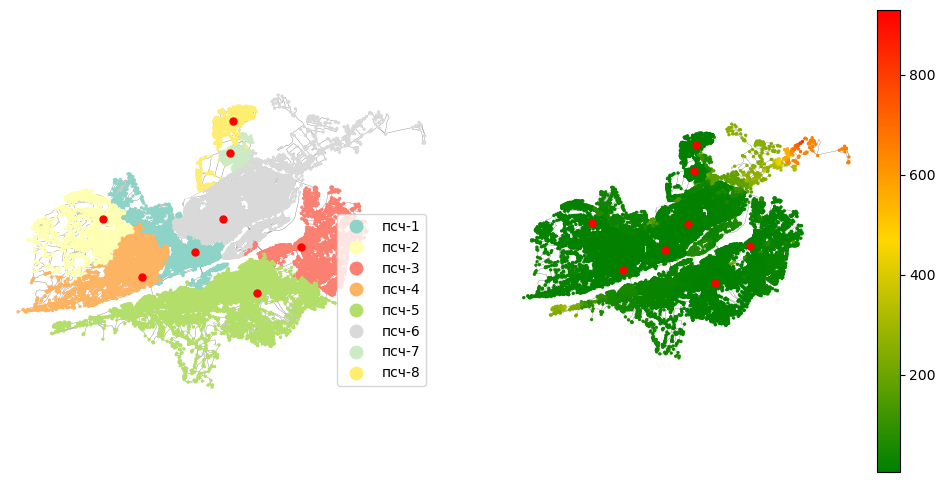

In [13]:
# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes)

## Расчет последовательно метриками max+mean time

{'best_metric': 9.936917216658468, 'dynamic_nodes': {356313823: 'псч-1', 358015031: 'псч-2', 457310528: 'псч-3', 860857666: 'псч-4', 1375952780: 'псч-5', 1706724199: 'псч-6', 1877319734: 'псч-7', 2041362008: 'псч-8'}, 'static_nodes': {}}
{'i': 0, 'best_metric': 9.32408849386146, 'dynamic_nodes': {346203074: 'псч-1', 8708033584: 'псч-2', 291319649: 'псч-3', 11630575964: 'псч-4', 2320451910: 'псч-5', 10037565957: 'псч-6', 276623982: 'псч-7', 4360987786: 'псч-8'}, 'static_nodes': {}}
{'i': 1, 'best_metric': 9.32408849386146, 'dynamic_nodes': {346203074: 'псч-1', 8708033584: 'псч-2', 291319649: 'псч-3', 11630575964: 'псч-4', 2320451910: 'псч-5', 10037565957: 'псч-6', 276623982: 'псч-7', 4360987786: 'псч-8'}, 'static_nodes': {}}
{'i': 2, 'best_metric': 9.32408849386146, 'dynamic_nodes': {346203074: 'псч-1', 8708033584: 'псч-2', 291319649: 'псч-3', 11630575964: 'псч-4', 2320451910: 'псч-5', 10037565957: 'псч-6', 276623982: 'псч-7', 4360987786: 'псч-8'}, 'static_nodes': {}}
{'i': 3, 'best_met

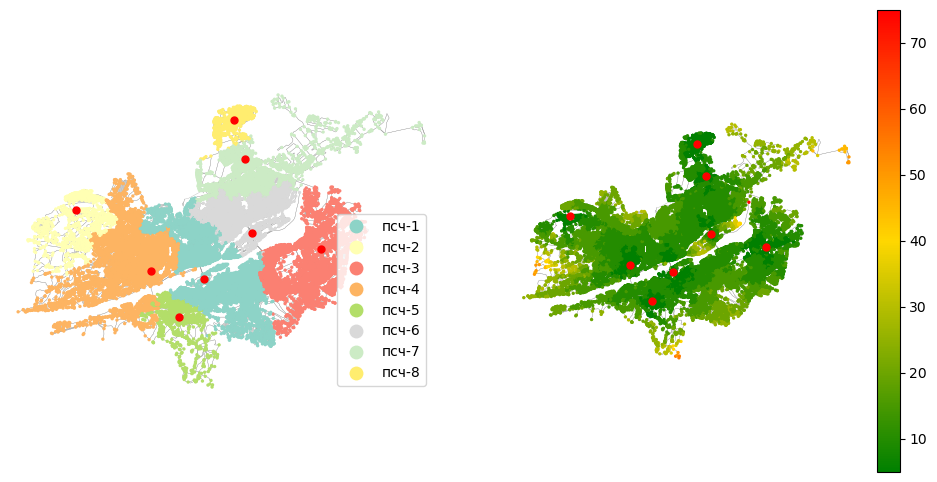

In [16]:
# Расчет метрикой max_time
BNHC_max = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(np.max),
                       )
BNG_max = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_max,
                       iterations=5,
                       ))
optimal_nodes, best_metric = BNG_max(env=G,
    dynamic_nodes=new_units,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )
# Расчет метрикой mean_time
BNHC_mean = BestNodeHillClimbing(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       )
BNG_mean = timing(BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function=ArrivalTime(),
                       best_point_function=BNHC_mean,
                       iterations=5,
                       ))
optimal_nodes, best_metric = BNG_mean(env=G,
    dynamic_nodes=optimal_nodes,
    before_iters_start_function=iter_func,
    iter_calc_end_function=iter_func,
    )

# Печать карт размещения и прибытия
iter_state_func(dynamic_nodes=optimal_nodes)

In [17]:
best_metric

8.442994079614454